<a href="https://colab.research.google.com/github/MasterNathan01/4106/blob/main/WatersNathan_801283595_HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install torchinfo
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import time
import numpy as np
from torchvision.models import resnet18
from torchinfo import summary

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class PatchEmbedding(nn.Module):
    """
    Split image into patches and embed.
    """
    def __init__(self, image_size, patch_size, in_channels=3, embed_dim=256):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2

        # Creating a Conv2d layer
        self.proj = nn.Conv2d(in_channels, embed_dim,
                            kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x shape: [B, C, H, W]
        x = self.proj(x)  # [B, embed_dim, H', W']
        x = x.flatten(2)  # [B, embed_dim, num_patches]
        x = x.transpose(1, 2)  # [B, num_patches, embed_dim]
        return x

class TransformerEncoder(nn.Module):
    """
    Transformer encoder block with multi-head self-attention.
    """
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.layer_norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # x shape: [B, num_patches + 1, embed_dim]

        # Layer Norm + Multi-Head Attention + Residual
        x_norm = self.layer_norm1(x)
        x_norm = x_norm.transpose(0, 1)  # [num_patches + 1, B, embed_dim]
        attn_output, _ = self.attention(x_norm, x_norm, x_norm)
        attn_output = attn_output.transpose(0, 1)  # [B, num_patches + 1, embed_dim]
        x = x + attn_output

        # Layer Norm + MLP + Residual
        x_norm = self.layer_norm2(x)
        mlp_output = self.mlp(x_norm)
        x = x + mlp_output

        return x

class VisionTransformer(nn.Module):
    """
    Vision Transformer for image classification.
    """
    def __init__(self, image_size, patch_size, num_classes, embed_dim,
                 num_heads, num_layers, mlp_dim, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size, patch_size, 3, embed_dim)

        # Class token and position embeddings
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        num_patches = (image_size // patch_size) ** 2
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.dropout = nn.Dropout(dropout)

        # Transformer encoder blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerEncoder(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ])

        # Layer norm and classification head
        self.layer_norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        # Initialize weights for linear layers and layer norms
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # x shape: [B, C, H, W]
        B = x.shape[0]

        # Create patch embeddings
        x = self.patch_embed(x)  # [B, num_patches, embed_dim]

        # Add class token
        cls_tokens = self.cls_token.expand(B, -1, -1)  # [B, 1, embed_dim]
        x = torch.cat((cls_tokens, x), dim=1)  # [B, 1 + num_patches, embed_dim]

        # Add position embeddings
        x = x + self.pos_embed
        x = self.dropout(x)

        # Apply transformer blocks
        for block in self.transformer_blocks:
            x = block(x)

        # Layer normalization and classification
        x = self.layer_norm(x)
        cls_token_final = x[:, 0]  # Take the class token representation
        x = self.head(cls_token_final)

        return x

def calculate_flops(model, input_size=(1, 3, 32, 32)):
    """
    Estimate FLOPs using torchinfo
    """
    stats = summary(model, input_size=input_size, verbose=0)
    # Convert to millions
    flops = stats.total_mult_adds * 2 / 10**6
    return flops

def count_parameters(model):
    """
    Count the total number of parameters
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_epoch(model, train_loader, criterion, optimizer, scheduler=None):
    """
    Train for one epoch
    """
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    start_time = time.time()

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        # Apply gradient clipping to prevent exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        total_loss += loss.item()

    if scheduler is not None:
        scheduler.step()

    epoch_time = time.time() - start_time
    train_accuracy = 100 * correct / total
    avg_loss = total_loss / len(train_loader)

    return avg_loss, train_accuracy, epoch_time

def evaluate(model, test_loader):
    """
    Evaluate model on test set
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

def train_model(model, train_loader, test_loader, num_epochs=30, learning_rate=0.001, weight_decay=0.05):
    """
    Train and evaluate a model
    """
    criterion = nn.CrossEntropyLoss()

    # AdamW with weight decay
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    # Model complexity metrics
    num_params = count_parameters(model)
    flops = calculate_flops(model)

    # Training and evaluation
    train_accuracies = []
    test_accuracies = []
    losses = []
    epoch_times = []

    print(f"\nTraining {model.__class__.__name__} with {num_params:,} parameters")
    print(f"Estimated FLOPs: {flops:.2f}M")

    for epoch in range(num_epochs):
        loss, train_acc, epoch_time = train_epoch(
            model, train_loader, criterion, optimizer, scheduler
        )
        test_acc = evaluate(model, test_loader)

        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        losses.append(loss)
        epoch_times.append(epoch_time)

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {loss:.4f}, Train Acc: {train_acc:.2f}%, '
              f'Test Acc: {test_acc:.2f}%, Time: {epoch_time:.2f}s')

        # Save 10th epoch metrics for comparison table
        if epoch == 9:
            tenth_epoch_metrics = {
                'test_acc': test_acc,
                'epoch_time': epoch_time
            }

    avg_epoch_time = sum(epoch_times) / len(epoch_times)

    metrics = {
        'model_name': model.__class__.__name__,
        'params': num_params,
        'flops': flops,
        'final_test_acc': test_accuracies[-1],
        'tenth_epoch_test_acc': tenth_epoch_metrics['test_acc'],
        'avg_epoch_time': avg_epoch_time,
        'tenth_epoch_time': tenth_epoch_metrics['epoch_time']
    }

    return metrics

def main():
    # Hyperparameters
    image_size = 32
    num_classes = 100
    batch_size = 64
    num_epochs = 30
    learning_rate = 0.0005
    weight_decay = 0.05     # Weight decay for regularization

    # Data preparation - improved normalization and augmentation
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.RandAugment(num_ops=2, magnitude=9),  # Adding RandAugment for better generalization
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
    ])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
    ])

    # CIFAR-100 dataset
    print("Loading CIFAR-100 dataset...")
    train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True,
                                              download=True, transform=train_transform)
    test_dataset = torchvision.datasets.CIFAR100(root='./data', train=False,
                                             download=True, transform=test_transform)

    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # ViT Configurations
    vit_configs = [
        {"name": "ViT-Tiny", "patch_size": 4, "embed_dim": 256, "num_layers": 4, "num_heads": 4, "mlp_dim": 1024, "dropout": 0.1},
        {"name": "ViT-Small", "patch_size": 4, "embed_dim": 512, "num_layers": 4, "num_heads": 8, "mlp_dim": 2048, "dropout": 0.1},
        {"name": "ViT-Medium", "patch_size": 8, "embed_dim": 256, "num_layers": 8, "num_heads": 4, "mlp_dim": 1024, "dropout": 0.2},
        {"name": "ViT-Large", "patch_size": 8, "embed_dim": 512, "num_layers": 8, "num_heads": 8, "mlp_dim": 2048, "dropout": 0.3},
    ]

    results = []

    # Train and evaluate each ViT configuration
    for config in vit_configs:
        print(f"\n{'='*50}")
        print(f"Training {config['name']} with:")
        print(f"Patch Size: {config['patch_size']}, Embed Dim: {config['embed_dim']}")
        print(f"Layers: {config['num_layers']}, Heads: {config['num_heads']}, MLP Dim: {config['mlp_dim']}")
        print(f"Dropout: {config['dropout']}")
        print(f"{'='*50}")

        # Initialize model
        model = VisionTransformer(
            image_size=image_size,
            patch_size=config['patch_size'],
            num_classes=num_classes,
            embed_dim=config['embed_dim'],
            num_heads=config['num_heads'],
            num_layers=config['num_layers'],
            mlp_dim=config['mlp_dim'],
            dropout=config['dropout']
        ).to(device)

        # Train and evaluate
        metrics = train_model(
            model,
            train_loader,
            test_loader,
            num_epochs,
            learning_rate,
            weight_decay
        )
        metrics['model_name'] = config['name']
        results.append(metrics)

    # ResNet-18 baseline
    print(f"\n{'='*50}")
    print(f"Training ResNet-18 baseline")
    print(f"{'='*50}")

    # Load ResNet-18 and modify for CIFAR-100
    resnet_model = resnet18(pretrained=True)
    resnet_model.fc = nn.Sequential(
        nn.Dropout(0.1),
        nn.Linear(512, num_classes)
    )
    resnet_model = resnet_model.to(device)

    resnet_metrics = train_model(
        resnet_model,
        train_loader,
        test_loader,
        num_epochs,
        learning_rate,
        weight_decay
    )
    resnet_metrics['model_name'] = 'ResNet-18'
    results.append(resnet_metrics)

    # Print results table
    print("\n\n" + "="*100)
    print("RESULTS SUMMARY")
    print("="*100)
    print(f"{'Model':<15} {'Params':<15} {'FLOPs (M)':<15} {'Test Acc (%)':<15} {'10th Epoch (%)':<15} {'Avg Time (s)':<15}")
    print("-"*100)

    for r in results:
        print(f"{r['model_name']:<15} {r['params']:<15,} {r['flops']:<15.2f} {r['final_test_acc']:<15.2f} {r['tenth_epoch_test_acc']:<15.2f} {r['avg_epoch_time']:<15.2f}")

    print("="*100)

if __name__ == '__main__':
    main()

Using device: cuda
Loading CIFAR-100 dataset...

Training ViT-Tiny with:
Patch Size: 4, Embed Dim: 256
Layers: 4, Heads: 4, MLP Dim: 1024
Dropout: 0.1

Training VisionTransformer with 3,214,692 parameters
Estimated FLOPs: 5.87M
Epoch [1/30], Train Loss: 4.1741, Train Acc: 6.42%, Test Acc: 12.81%, Time: 20.46s
Epoch [2/30], Train Loss: 3.7791, Train Acc: 12.09%, Test Acc: 17.78%, Time: 20.91s
Epoch [3/30], Train Loss: 3.5770, Train Acc: 15.08%, Test Acc: 21.02%, Time: 20.90s
Epoch [4/30], Train Loss: 3.4284, Train Acc: 17.71%, Test Acc: 23.84%, Time: 21.03s
Epoch [5/30], Train Loss: 3.3222, Train Acc: 19.38%, Test Acc: 26.96%, Time: 20.91s
Epoch [6/30], Train Loss: 3.2246, Train Acc: 21.42%, Test Acc: 27.17%, Time: 21.58s
Epoch [7/30], Train Loss: 3.1399, Train Acc: 22.85%, Test Acc: 30.17%, Time: 20.86s
Epoch [8/30], Train Loss: 3.0738, Train Acc: 24.27%, Test Acc: 31.29%, Time: 20.77s
Epoch [9/30], Train Loss: 2.9869, Train Acc: 25.74%, Test Acc: 33.13%, Time: 21.06s
Epoch [10/30], Tr

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 155MB/s]



Training ResNet with 11,227,812 parameters
Estimated FLOPs: 74.14M
Epoch [1/30], Train Loss: 3.3591, Train Acc: 19.48%, Test Acc: 33.94%, Time: 20.81s
Epoch [2/30], Train Loss: 2.7177, Train Acc: 30.92%, Test Acc: 41.73%, Time: 20.29s
Epoch [3/30], Train Loss: 2.4991, Train Acc: 35.61%, Test Acc: 43.37%, Time: 20.32s
Epoch [4/30], Train Loss: 2.3586, Train Acc: 38.76%, Test Acc: 46.57%, Time: 20.57s
Epoch [5/30], Train Loss: 2.2632, Train Acc: 40.56%, Test Acc: 48.01%, Time: 20.83s
Epoch [6/30], Train Loss: 2.1594, Train Acc: 42.87%, Test Acc: 49.51%, Time: 20.65s
Epoch [7/30], Train Loss: 2.0925, Train Acc: 44.29%, Test Acc: 50.93%, Time: 21.64s
Epoch [8/30], Train Loss: 2.0185, Train Acc: 45.80%, Test Acc: 51.71%, Time: 20.51s
Epoch [9/30], Train Loss: 1.9664, Train Acc: 47.40%, Test Acc: 52.69%, Time: 21.96s
Epoch [10/30], Train Loss: 1.9011, Train Acc: 48.50%, Test Acc: 52.88%, Time: 20.30s
Epoch [11/30], Train Loss: 1.8432, Train Acc: 50.08%, Test Acc: 53.53%, Time: 20.47s
Epoch 

Using device: cuda

Fine-tuning microsoft/swin-tiny-patch4-window7-224...


Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([100]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([100, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 27,596,254
Trainable parameters: 76,900


Testing: 100%|██████████| 313/313 [00:22<00:00, 14.02it/s]


Epoch 1/5, Loss: 4.0409, Test Accuracy: 47.67%, Time: 112.66s


...

Epoch 3/5, Loss: 4.6136, Test Accuracy: 1.08%, Time: 219.01s


Testing: 100%|██████████| 313/313 [00:21<00:00, 14.48it/s]


Epoch 4/5, Loss: 4.5928, Test Accuracy: 1.13%, Time: 218.64s


Testing: 100%|██████████| 313/313 [00:21<00:00, 14.50it/s]


Epoch 5/5, Loss: 4.6072, Test Accuracy: 1.00%, Time: 219.14s

Final Test Accuracy: 1.00%
Total Training Time: 1095.38s
Average Loss: 4.6072
Average Time per Epoch: 219.08s
Parameters: 27,897,310
Trainable Parameters: 27,897,310

===== RESULTS COMPARISON =====
Model                | Final Accuracy (%)   | Avg Time/Epoch (s)   | Total Parameters     | Trainable Parameters
--------------------------------------------------------------------------------------------------------------
swin-tiny-patch4-window7-224 | 66.54                | 112.72               | 27,596,254           | 76,900              
swin-small-patch4-window7-224 | 70.72                | 149.73               | 48,914,158           | 76,900              
Swin-Scratch         | 1.00                 | 219.08               | 27,897,310           | 27,897,310          


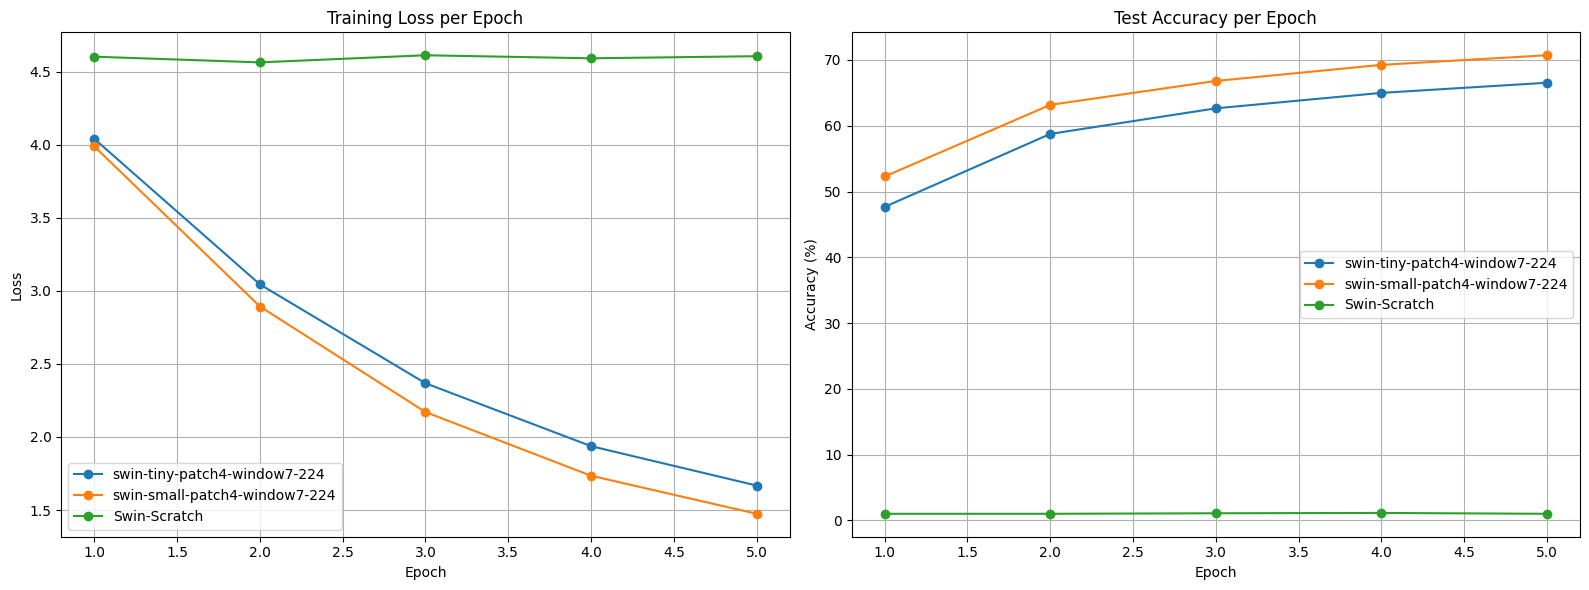

In [7]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from transformers import SwinForImageClassification, AutoImageProcessor
from tqdm import tqdm
import time
import numpy as np
import matplotlib.pyplot as plt
import math
try:
    from torchinfo import summary
except ImportError:
    !pip install torchinfo
    from torchinfo import summary

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
num_epochs = 5
batch_size = 32
learning_rate = 0.001  # For from-scratch
fine_tune_lr = 2e-5    # For fine-tuning
image_size = 224       # Swin expects 224x224 input

# Function to count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Function to fine-tune a Swin Transformer model
def fine_tune_swin(model_name, num_labels=100):
    print(f"\nFine-tuning {model_name}...")

    # Data preparation with proper preprocessing for Swin
    processor = AutoImageProcessor.from_pretrained(model_name)

    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ])

    # CIFAR-100 dataset
    train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True,
                                             download=True, transform=transform)
    test_dataset = torchvision.datasets.CIFAR100(root='./data', train=False,
                                            download=True, transform=transform)

    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

    # Load pretrained Swin Transformer
    model = SwinForImageClassification.from_pretrained(
        model_name,
        num_labels=num_labels,  # CIFAR-100 has 100 classes
        ignore_mismatched_sizes=True  # Allows replacing the original classifier head
    ).to(device)

    # Freeze backbone parameters and only train the classification head
    for param in model.swin.parameters():
        param.requires_grad = False

    # Only the classifier head will be trained
    for param in model.classifier.parameters():
        param.requires_grad = True

    # Count trainable parameters
    trainable_params = count_parameters(model)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.classifier.parameters(), lr=fine_tune_lr)

    # Training loop
    epoch_times = []
    train_losses = []
    test_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        start_time = time.time()

        progress_bar = tqdm(train_loader, desc=f'Epoch [{epoch+1}/{num_epochs}]')
        for i, (images, labels) in enumerate(progress_bar):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images).logits
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if (i+1) % 100 == 0:
                progress_bar.set_postfix({'loss': loss.item()})

        epoch_time = time.time() - start_time
        epoch_times.append(epoch_time)

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Test accuracy after each epoch
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            for images, labels in tqdm(test_loader, desc='Testing'):
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images).logits
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            accuracy = 100 * correct / total
            test_accuracies.append(accuracy)
            print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%, Time: {epoch_time:.2f}s')

    # Final evaluation
    print(f"\nFinal test accuracy: {test_accuracies[-1]:.2f}%")
    print(f"Average training time per epoch: {np.mean(epoch_times):.2f}s")

    return {
        'model_name': model_name.split('/')[-1],
        'accuracy': test_accuracies[-1],
        'training_time': np.mean(epoch_times),
        'parameters': total_params,
        'trainable_parameters': trainable_params,
        'train_losses': train_losses,
        'test_accuracies': test_accuracies
    }

# Properly implemented Swin Transformer from scratch
class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=4, in_chans=3, embed_dim=96, norm_layer=None):
        super().__init__()
        img_size = (img_size, img_size)
        patch_size = (patch_size, patch_size)

        self.img_size = img_size
        self.patch_size = patch_size
        self.patches_resolution = [img_size[0] // patch_size[0], img_size[1] // patch_size[1]]
        self.num_patches = self.patches_resolution[0] * self.patches_resolution[1]

        self.in_chans = in_chans
        self.embed_dim = embed_dim

        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = norm_layer(embed_dim) if norm_layer else nn.LayerNorm(embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape
        # Make sure the input is properly resized
        assert H == self.img_size[0] and W == self.img_size[1], \
            f"Input image size ({H}*{W}) doesn't match model ({self.img_size[0]}*{self.img_size[1]})"

        # Embedding using convolution
        x = self.proj(x).flatten(2).transpose(1, 2)  # B Ph*Pw C
        x = self.norm(x)
        return x

def window_partition(x, window_size):
    """
    Args:
        x: (B, H, W, C)
        window_size (int): window size
    Returns:
        windows: (num_windows*B, window_size, window_size, C)
    """
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size, H, W):
    """
    Args:
        windows: (num_windows*B, window_size, window_size, C)
        window_size (int): Window size
        H (int): Height of image
        W (int): Width of image
    Returns:
        x: (B, H, W, C)
    """
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x

class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads, qkv_bias=True, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.dim = dim
        self.window_size = window_size  # Wh, Ww
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        # Define a parameter table of relative position bias
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * window_size[0] - 1) * (2 * window_size[1] - 1), num_heads))

        # Get pair-wise relative position index for each token inside the window
        coords_h = torch.arange(self.window_size[0])
        coords_w = torch.arange(self.window_size[1])
        coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing="ij"))  # 2, Wh, Ww
        coords_flatten = torch.flatten(coords, 1)  # 2, Wh*Ww
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]  # 2, Wh*Ww, Wh*Ww
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()  # Wh*Ww, Wh*Ww, 2
        relative_coords[:, :, 0] += self.window_size[0] - 1  # shift to start from 0
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1
        relative_position_index = relative_coords.sum(-1)  # Wh*Ww, Wh*Ww
        self.register_buffer("relative_position_index", relative_position_index)

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

        nn.init.trunc_normal_(self.relative_position_bias_table, std=.02)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, mask=None):
        """
        Args:
            x: input features with shape of (num_windows*B, N, C)
            mask: (0/-inf) mask with shape of (num_windows, Wh*Ww, Wh*Ww) or None
        """
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # make torchscript happy (cannot use tensor as tuple)

        q = q * self.scale
        attn = (q @ k.transpose(-2, -1))

        relative_position_bias = self.relative_position_bias_table[self.relative_position_index.view(-1)].view(
            self.window_size[0] * self.window_size[1], self.window_size[0] * self.window_size[1], -1)  # Wh*Ww,Wh*Ww,nH
        relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous()  # nH, Wh*Ww, Wh*Ww
        attn = attn + relative_position_bias.unsqueeze(0)

        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)

        attn = self.softmax(attn)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, input_resolution, num_heads, window_size=7, shift_size=0,
                 mlp_ratio=4., qkv_bias=True, drop=0., attn_drop=0., drop_path=0.,
                 act_layer=nn.GELU, norm_layer=nn.LayerNorm):
        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size
        self.mlp_ratio = mlp_ratio

        if min(self.input_resolution) <= self.window_size:
            # If window size is larger than input resolution, no need for SW-MSA
            self.shift_size = 0
            self.window_size = min(self.input_resolution)

        self.norm1 = norm_layer(dim)

        self.attn = WindowAttention(
            dim, window_size=(self.window_size, self.window_size),
            num_heads=num_heads, qkv_bias=qkv_bias,
            attn_drop=attn_drop, proj_drop=drop)

        self.drop_path = nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

        if self.shift_size > 0:
            # Calculate attention mask for SW-MSA
            H, W = self.input_resolution
            img_mask = torch.zeros((1, H, W, 1))
            h_slices = (slice(0, -self.window_size),
                        slice(-self.window_size, -self.shift_size),
                        slice(-self.shift_size, None))
            w_slices = (slice(0, -self.window_size),
                        slice(-self.window_size, -self.shift_size),
                        slice(-self.shift_size, None))
            cnt = 0
            for h in h_slices:
                for w in w_slices:
                    img_mask[:, h, w, :] = cnt
                    cnt += 1

            mask_windows = window_partition(img_mask, self.window_size)  # nW, window_size, window_size, 1
            mask_windows = mask_windows.view(-1, self.window_size * self.window_size)
            attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
            attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))
        else:
            attn_mask = None

        self.register_buffer("attn_mask", attn_mask)

    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape
        assert L == H * W, "input feature has wrong size"

        shortcut = x
        x = self.norm1(x)
        x = x.view(B, H, W, C)

        # cyclic shift
        if self.shift_size > 0:
            shifted_x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))
        else:
            shifted_x = x

        # partition windows
        x_windows = window_partition(shifted_x, self.window_size)  # nW*B, window_size, window_size, C
        x_windows = x_windows.view(-1, self.window_size * self.window_size, C)  # nW*B, window_size*window_size, C

        # W-MSA/SW-MSA
        attn_windows = self.attn(x_windows, mask=self.attn_mask)  # nW*B, window_size*window_size, C

        # merge windows
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        shifted_x = window_reverse(attn_windows, self.window_size, H, W)  # B H' W' C

        # reverse cyclic shift
        if self.shift_size > 0:
            x = torch.roll(shifted_x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))
        else:
            x = shifted_x

        x = x.view(B, H * W, C)

        # FFN
        x = shortcut + self.drop_path(x)
        x = x + self.drop_path(self.mlp(self.norm2(x)))

        return x

class PatchMerging(nn.Module):
    def __init__(self, input_resolution, dim, norm_layer=nn.LayerNorm):
        super().__init__()
        self.input_resolution = input_resolution
        self.dim = dim
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = norm_layer(4 * dim)

    def forward(self, x):
        """
        x: B, H*W, C
        """
        H, W = self.input_resolution
        B, L, C = x.shape
        assert L == H * W, "input feature has wrong size"
        assert H % 2 == 0 and W % 2 == 0, f"x size ({H}*{W}) are not even."

        x = x.view(B, H, W, C)

        x0 = x[:, 0::2, 0::2, :]  # B H/2 W/2 C
        x1 = x[:, 1::2, 0::2, :]  # B H/2 W/2 C
        x2 = x[:, 0::2, 1::2, :]  # B H/2 W/2 C
        x3 = x[:, 1::2, 1::2, :]  # B H/2 W/2 C
        x = torch.cat([x0, x1, x2, x3], -1)  # B H/2 W/2 4*C
        x = x.view(B, -1, 4 * C)  # B H/2*W/2 4*C

        x = self.norm(x)
        x = self.reduction(x)

        return x

class BasicLayer(nn.Module):
    def __init__(self, dim, input_resolution, depth, num_heads, window_size,
                 mlp_ratio=4., qkv_bias=True, drop=0., attn_drop=0.,
                 drop_path=0., norm_layer=nn.LayerNorm, downsample=None, use_checkpoint=False):
        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.depth = depth
        self.use_checkpoint = use_checkpoint

        # build blocks
        self.blocks = nn.ModuleList([
            SwinTransformerBlock(
                dim=dim, input_resolution=input_resolution,
                num_heads=num_heads, window_size=window_size,
                shift_size=0 if (i % 2 == 0) else window_size // 2,
                mlp_ratio=mlp_ratio,
                qkv_bias=qkv_bias,
                drop=drop, attn_drop=attn_drop,
                drop_path=drop_path,
                norm_layer=norm_layer)
            for i in range(depth)])

        # patch merging layer
        if downsample is not None:
            self.downsample = downsample(input_resolution, dim=dim, norm_layer=norm_layer)
        else:
            self.downsample = None

    def forward(self, x):
        for blk in self.blocks:
            x = blk(x)
        if self.downsample is not None:
            x = self.downsample(x)
        return x

class SwinTransformerFromScratch(nn.Module):
    def __init__(self, img_size=224, patch_size=4, in_chans=3, num_classes=100,
                embed_dim=96, depths=[2, 2, 6, 2], num_heads=[3, 6, 12, 24],
                window_size=7, mlp_ratio=4., qkv_bias=True, drop_rate=0.,
                attn_drop_rate=0., drop_path_rate=0.1, norm_layer=nn.LayerNorm,
                patch_norm=True, use_checkpoint=False, **kwargs):
        super().__init__()

        self.num_classes = num_classes
        self.num_layers = len(depths)
        self.embed_dim = embed_dim
        self.patch_norm = patch_norm
        self.num_features = int(embed_dim * 2 ** (self.num_layers - 1))
        self.mlp_ratio = mlp_ratio

        # split image into non-overlapping patches
        self.patch_embed = PatchEmbed(
            img_size=img_size, patch_size=patch_size, in_chans=in_chans, embed_dim=embed_dim,
            norm_layer=norm_layer if self.patch_norm else None)
        num_patches = self.patch_embed.num_patches
        patches_resolution = self.patch_embed.patches_resolution
        self.patches_resolution = patches_resolution

        # absolute position embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)

        # stochastic depth
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]  # stochastic depth decay rule

        # build layers
        self.layers = nn.ModuleList()
        for i_layer in range(self.num_layers):
            layer = BasicLayer(
                dim=int(embed_dim * 2 ** i_layer),
                input_resolution=(patches_resolution[0] // (2 ** i_layer),
                                  patches_resolution[1] // (2 ** i_layer)),
                depth=depths[i_layer],
                num_heads=num_heads[i_layer],
                window_size=window_size,
                mlp_ratio=self.mlp_ratio,
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[sum(depths[:i_layer]):sum(depths[:i_layer + 1])],
                norm_layer=norm_layer,
                downsample=PatchMerging if (i_layer < self.num_layers - 1) else None,
                use_checkpoint=use_checkpoint)
            self.layers.append(layer)

        self.norm = norm_layer(self.num_features)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(self.num_features, num_classes) if num_classes > 0 else nn.Identity()

        # Initialize weights
        nn.init.trunc_normal_(self.pos_embed, std=.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward_features(self, x):
        x = self.patch_embed(x)
        x = x + self.pos_embed
        x = self.pos_drop(x)

        for layer in self.layers:
            x = layer(x)

        x = self.norm(x)  # B L C
        x = self.avgpool(x.transpose(1, 2))  # B C 1
        x = torch.flatten(x, 1)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x

# Function to train Swin Transformer from scratch
def train_swin_from_scratch(num_labels=100):
    print("\nTraining Swin Transformer from scratch...")

    # Data preparation
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    # CIFAR-100 dataset
    train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True,
                                             download=True, transform=transform)
    test_dataset = torchvision.datasets.CIFAR100(root='./data', train=False,
                                            download=True, transform=transform)

    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

    # Create a Swin Transformer model from scratch - similar to Tiny configuration
    # Using smaller depth values to reduce training time
    model = SwinTransformerFromScratch(
        img_size=224,
        patch_size=4,
        in_chans=3,
        num_classes=num_labels,
        embed_dim=96,
        depths=[2, 2, 6, 2],  # Same as Swin-Tiny
        num_heads=[3, 6, 12, 24],
        window_size=7,
        mlp_ratio=4.,
        qkv_bias=True,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.1
    ).to(device)

    # Print model summary
    try:
        summary(model, input_size=(batch_size, 3, 224, 224))
    except:
        print("Could not generate model summary, continuing...")

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = count_parameters(model)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    epoch_times = []
    train_losses = []
    test_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        start_time = time.time()

        progress_bar = tqdm(train_loader, desc=f'Epoch [{epoch+1}/{num_epochs}]')
        for i, (images, labels) in enumerate(progress_bar):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if (i+1) % 100 == 0:
                progress_bar.set_postfix({'loss': loss.item()})

        epoch_time = time.time() - start_time
        epoch_times.append(epoch_time)

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Test accuracy after each epoch
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            for images, labels in tqdm(test_loader, desc='Testing'):
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            accuracy = 100 * correct / total
            test_accuracies.append(accuracy)
            print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%, Time: {epoch_time:.2f}s')

    # Final evaluation
    print(f"\nFinal Test Accuracy: {test_accuracies[-1]:.2f}%")
    print(f"Total Training Time: {sum(epoch_times):.2f}s")
    print(f"Average Loss: {train_losses[-1]:.4f}")
    print(f"Average Time per Epoch: {sum(epoch_times) / num_epochs:.2f}s")
    print(f"Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")

    return {
        'model_name': 'SwinTransformerFromScratch',
        'accuracy': test_accuracies[-1],
        'training_time': np.mean(epoch_times),
        'parameters': total_params,
        'trainable_parameters': trainable_params,
        'train_losses': train_losses,
        'test_accuracies': test_accuracies
    }

def plot_results(results_list):
    plt.figure(figsize=(16, 6))

    # Plot training loss
    plt.subplot(1, 2, 1)
    for result in results_list:
        plt.plot(range(1, num_epochs + 1), result['train_losses'],
                 marker='o', label=f"{result['model_name']}")
    plt.title('Training Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    # Plot test accuracy
    plt.subplot(1, 2, 2)
    for result in results_list:
        plt.plot(range(1, num_epochs + 1), result['test_accuracies'],
                 marker='o', label=f"{result['model_name']}")
    plt.title('Test Accuracy per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig('swin_comparison_results.png')
    plt.show()

# Function to display results in a table
def display_results_table(results_list):
    print("\n===== RESULTS COMPARISON =====")
    print(f"{'Model':<20} | {'Final Accuracy (%)':<20} | {'Avg Time/Epoch (s)':<20} | {'Total Parameters':<20} | {'Trainable Parameters':<20}")
    print("-" * 110)

    for result in results_list:
        print(f"{result['model_name']:<20} | {result['accuracy']:<20.2f} | {result['training_time']:<20.2f} | {result['parameters']:<20,} | {result['trainable_parameters']:<20,}")

# Main execution
if __name__ == "__main__":
    results = []

    # Fine-tune Swin-Tiny
    tiny_results = fine_tune_swin("microsoft/swin-tiny-patch4-window7-224")
    results.append(tiny_results)

    # Fine-tune Swin-Small
    small_results = fine_tune_swin("microsoft/swin-small-patch4-window7-224")
    results.append(small_results)

    # Train Swin Transformer from scratch
    scratch_results = train_swin_from_scratch()
    scratch_results['model_name'] = 'Swin-Scratch'
    results.append(scratch_results)

    # Display results
    display_results_table(results)

    # Plot training curves
    plot_results(results)